In [2]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

### 240311

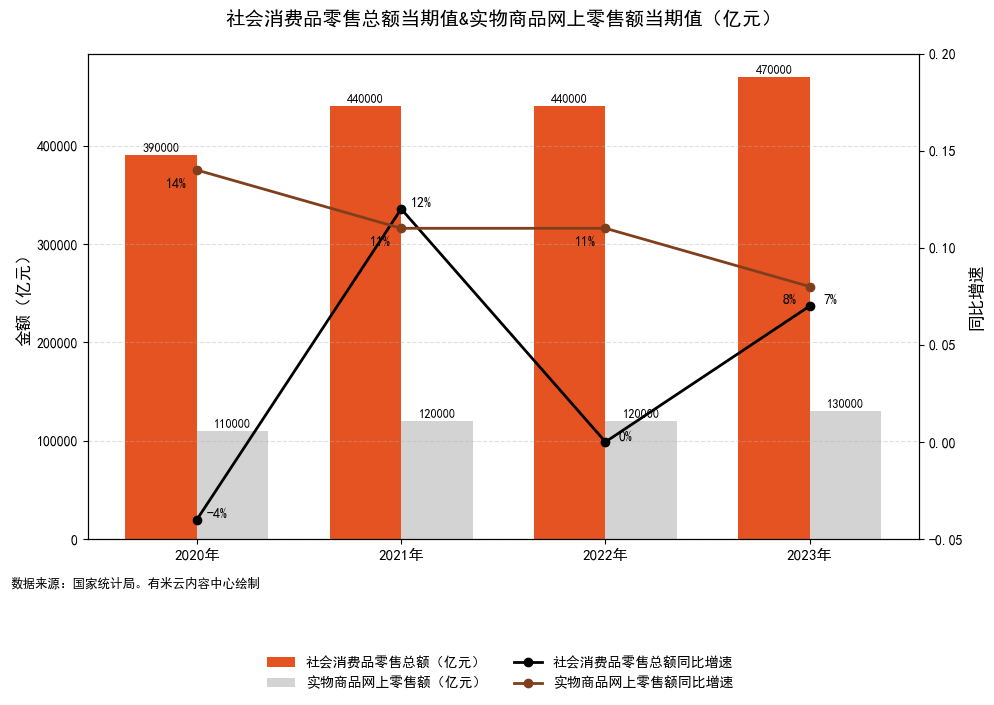

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
years = ['2020年', '2021年', '2022年', '2023年']
total_retail = [390000, 440000, 440000, 470000]  # 社会消费品零售总额（亿元）
online_retail = [110000, 120000, 120000, 130000]  # 实物商品网上零售额（亿元）
total_growth = [-0.04, 0.12, 0.00, 0.07]  # 同比增长率
online_growth = [0.14, 0.11, 0.11, 0.08]

x = np.arange(len(years))
width = 0.35

# 创建图形
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# 柱状图
bar1 = ax1.bar(x - width/2, total_retail, width, label='社会消费品零售总额（亿元）', color='#e55322')
bar2 = ax1.bar(x + width/2, online_retail, width, label='实物商品网上零售额（亿元）', color='lightgray')

# 条形图数据标注
for i, rect in enumerate(bar1):
    height = rect.get_height()
    ax1.text(rect.get_x() + rect.get_width()/2, height + 1000, f'{height}', ha='center', va='bottom', fontsize=9)

for i, rect in enumerate(bar2):
    height = rect.get_height()
    ax1.text(rect.get_x() + rect.get_width()/2, height + 1000, f'{height}', ha='center', va='bottom', fontsize=9)

# 折线图
line1 = ax2.plot(x, total_growth, label='社会消费品零售总额同比增速', color='black', marker='o', linewidth=2)
line2 = ax2.plot(x, online_growth, label='实物商品网上零售额同比增速', color='#7f3f1d', marker='o', linewidth=2)

# 增长率标注
for i, v in enumerate(total_growth):
    ax2.text(x[i] + 0.1, v, f'{int(v * 100)}%', ha='center', va='bottom', fontsize=10)

for i, v in enumerate(online_growth):
    ax2.text(x[i] - 0.1, v - 0.01, f'{int(v * 100)}%', ha='center', va='bottom', fontsize=10)

# 坐标轴与图例
ax1.set_ylabel('金额（亿元）', fontsize=12)
ax2.set_ylabel('同比增速', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(years, fontsize=11)
plt.title('社会消费品零售总额当期值&实物商品网上零售额当期值（亿元）', fontsize=14, pad=20)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False, fontsize=10)

# 网格和背景
ax1.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_ylim(-0.05, 0.20)
ax1.set_facecolor('white')

# 数据来源（用 fig.text 放在底部外部）
fig.text(0.01, 0.01, '数据来源：国家统计局。有米云内容中心绘制', ha='left', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 1])  # 给底部文本留空间
plt.show()

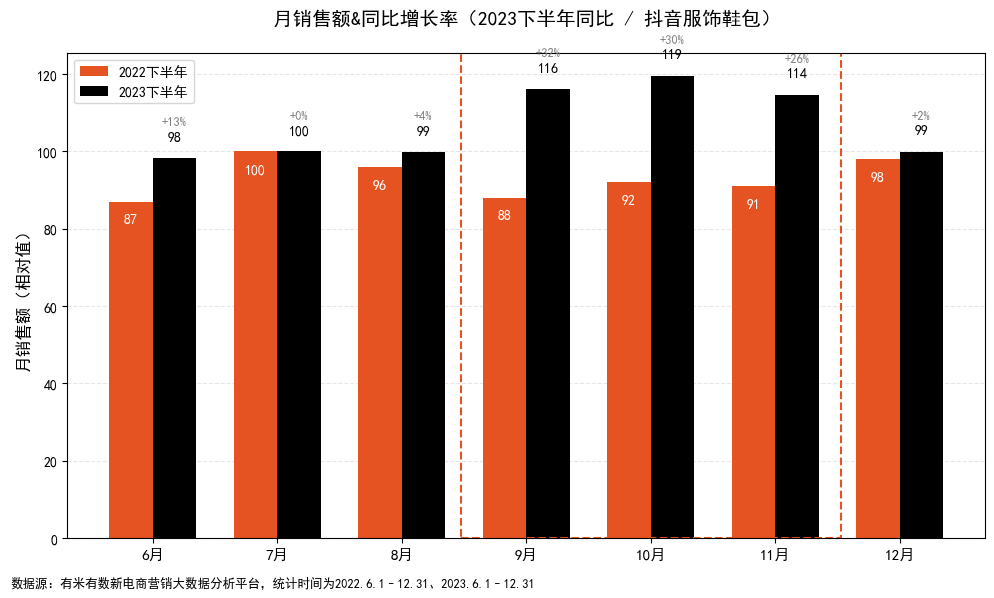

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# 数据
months = ['6月', '7月', '8月', '9月', '10月', '11月', '12月']
data_2022 = [87, 100, 96, 88, 92, 91, 98]  # 构造型数值
growth = [0.13, 0.0, 0.04, 0.32, 0.30, 0.26, 0.02]
data_2023 = [data_2022[i] * (1 + growth[i]) for i in range(len(data_2022))]

x = np.arange(len(months))
width = 0.35

# 创建图表
fig, ax = plt.subplots(figsize=(10, 6))

# 柱状图绘制
bars_2022 = ax.bar(x - width/2, data_2022, width, label='2022下半年', color='#e55322')
bars_2023 = ax.bar(x + width/2, data_2023, width, label='2023下半年', color='black')

# 添加数值标注（2022和2023）
for i in range(len(x)):
    # 2022柱子 - 内部标注
    ax.text(x[i] - width/2, data_2022[i] - 3,
            f'{int(data_2022[i])}', ha='center', va='top', fontsize=10, color='white')

    # 2023柱子 - 顶部外部标注
    ax.text(x[i] + width/2, data_2023[i] + 4,
            f'{int(data_2023[i])}', ha='center', va='bottom', fontsize=10, color='black')

# 添加增长率注释（略微上移）
for i, (x_pos, val) in enumerate(zip(x, data_2023)):
    ax.text(x_pos + width/2, val + 8,
            f'+{int(growth[i]*100)}%', ha='center', va='bottom', fontsize=9, color='gray')

# 坐标轴与标签
ax.set_xticks(x)
ax.set_xticklabels(months, fontsize=11)
ax.set_ylabel('月销售额（相对值）', fontsize=12)
plt.title('月销售额&同比增长率（2023下半年同比 / 抖音服饰鞋包）', fontsize=14, pad=20)

# 图例
ax.legend(loc='upper left', fontsize=10)

# 虚线框突出9–11月
highlight_start = x[3] - width*1.5
highlight_width = (x[5] - x[3]) + width*3
rect = patches.Rectangle(
    (highlight_start, 0), highlight_width, max(data_2023) * 1.2,
    linewidth=1.5, edgecolor='#e55322', linestyle='--', facecolor='none'
)
ax.add_patch(rect)

# 数据来源注释
fig.text(0.01, 0.01,
         '数据源：有米有数新电商营销大数据分析平台，统计时间为2022.6.1–12.31、2023.6.1–12.31',
         ha='left', va='bottom', fontsize=9)

# 网格
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


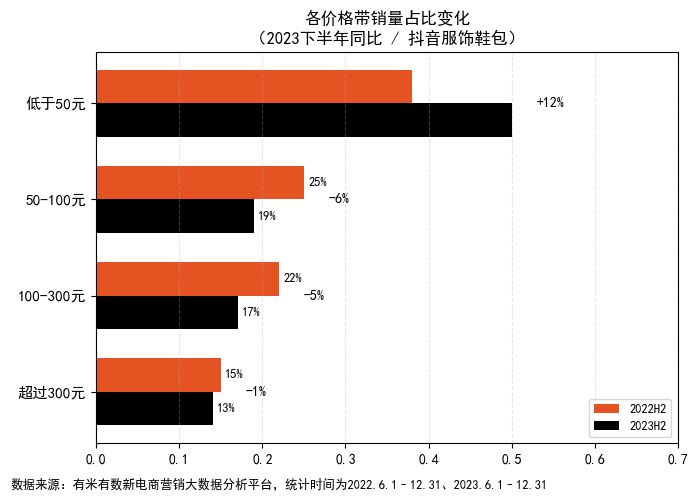

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
price_bands = ['低于50元', '50-100元', '100-300元', '超过300元']
volume_2022 = [0.38, 0.25, 0.22, 0.15]
volume_2023 = [v + d for v, d in zip(volume_2022, [0.12, -0.06, -0.05, -0.01])]
volume_change = ['+12%', '-6%', '-5%', '-1%']

# 绘图
fig, ax = plt.subplots(figsize=(7, 5))
y = np.arange(len(price_bands))
bar_height = 0.35

# 条形图
ax.barh(y - bar_height / 2, volume_2022, height=bar_height, color='#e55322', label='2022H2')
ax.barh(y + bar_height / 2, volume_2023, height=bar_height, color='black', label='2023H2')

# 数值标注
for i in range(len(price_bands)):
    ax.text(volume_2022[i] + 0.005, y[i] - bar_height / 2,
            f'{int(volume_2022[i]*100)}%', va='center', ha='left', fontsize=9,
            color='white' if volume_2022[i] > 0.3 else 'black')
    ax.text(volume_2023[i] + 0.005, y[i] + bar_height / 2,
            f'{int(volume_2023[i]*100)}%', va='center', ha='left', fontsize=9,
            color='white' if volume_2023[i] > 0.3 else 'black')
    ax.text(max(volume_2022[i], volume_2023[i]) + 0.03, y[i],
            volume_change[i], va='center', fontsize=10)

# 样式
ax.set_title('各价格带销量占比变化\n（2023下半年同比 / 抖音服饰鞋包）', fontsize=12)
ax.set_yticks(y)
ax.set_yticklabels(price_bands, fontsize=11)
ax.set_xlim(0, max(volume_2023) + 0.2)
ax.invert_yaxis()
ax.legend(loc='lower right', fontsize=9)
ax.xaxis.grid(True, linestyle='--', alpha=0.3)

# 数据来源
fig.text(0.01, 0.01,
         '数据来源：有米有数新电商营销大数据分析平台，统计时间为2022.6.1–12.31、2023.6.1–12.31',
         ha='left', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


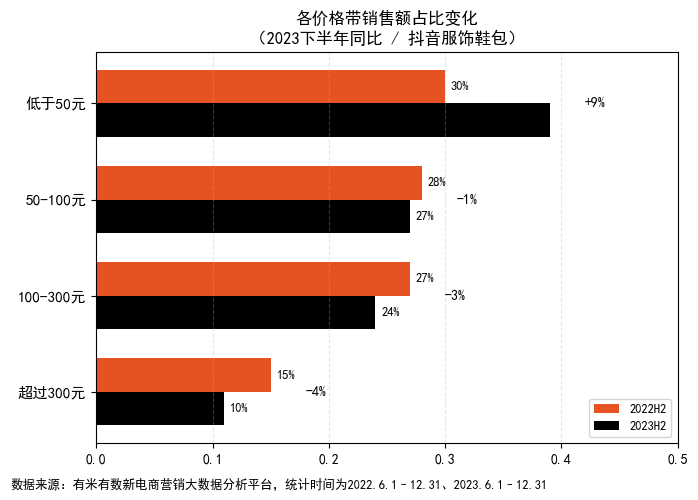

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
price_bands = ['低于50元', '50-100元', '100-300元', '超过300元']
value_2022 = [0.30, 0.28, 0.27, 0.15]
value_2023 = [v + d for v, d in zip(value_2022, [0.09, -0.01, -0.03, -0.04])]
value_change = ['+9%', '-1%', '-3%', '-4%']

# 绘图
fig, ax = plt.subplots(figsize=(7, 5))
y = np.arange(len(price_bands))
bar_height = 0.35

# 条形图
ax.barh(y - bar_height / 2, value_2022, height=bar_height, color='#e55322', label='2022H2')
ax.barh(y + bar_height / 2, value_2023, height=bar_height, color='black', label='2023H2')

# 数值标注
for i in range(len(price_bands)):
    ax.text(value_2022[i] + 0.005, y[i] - bar_height / 2,
            f'{int(value_2022[i]*100)}%', va='center', ha='left', fontsize=9,
            color='white' if value_2022[i] > 0.3 else 'black')
    ax.text(value_2023[i] + 0.005, y[i] + bar_height / 2,
            f'{int(value_2023[i]*100)}%', va='center', ha='left', fontsize=9,
            color='white' if value_2023[i] > 0.3 else 'black')
    ax.text(max(value_2022[i], value_2023[i]) + 0.03, y[i],
            value_change[i], va='center', fontsize=10)

# 样式
ax.set_title('各价格带销售额占比变化\n（2023下半年同比 / 抖音服饰鞋包）', fontsize=12)
ax.set_yticks(y)
ax.set_yticklabels(price_bands, fontsize=11)
ax.set_xlim(0, max(value_2022) + 0.2)
ax.invert_yaxis()
ax.legend(loc='lower right', fontsize=9)
ax.xaxis.grid(True, linestyle='--', alpha=0.3)

# 数据来源
fig.text(0.01, 0.01,
         '数据来源：有米有数新电商营销大数据分析平台，统计时间为2022.6.1–12.31、2023.6.1–12.31',
         ha='left', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()
